In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading a dataset 

In [4]:
df = pd.read_csv("test.csv")

In [6]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [8]:
# Check for missing values
print(df.isnull().sum())

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64


In [9]:
df_clean = df.dropna()

In [12]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,362.000000,361.000000,338.000000
mean,4805.599455,1569.577657,136.132597,342.537396,0.825444
std,4910.685399,2334.232099,61.366652,65.156643,0.380150
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,100.250000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,158.000000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


In [14]:
print(df.columns)

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')


In [15]:
#Distribution of Loan Amount

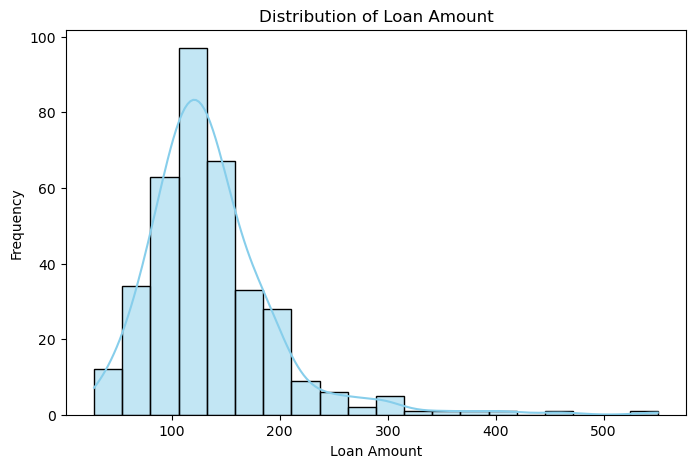

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['LoanAmount'], bins=20, kde=True, color='skyblue')
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

In [18]:
#Education vs Loan Amount (Box Plot)

C:\Users\Mubarik Amin\AppData\Local\Temp\ipykernel_3708\3300354143.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Education', y='LoanAmount', data=df, palette='Set2')


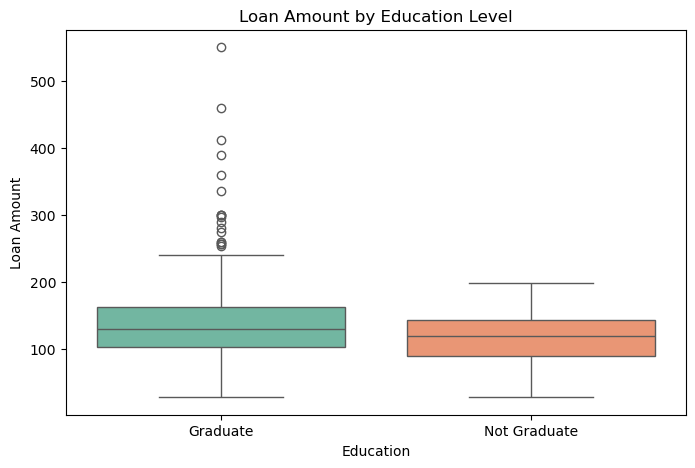

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Education', y='LoanAmount', data=df, palette='Set2')
plt.title("Loan Amount by Education Level")
plt.xlabel("Education")
plt.ylabel("Loan Amount")
plt.show()

In [20]:
#Applicant Income vs Loan Amount (Scatter Plot)

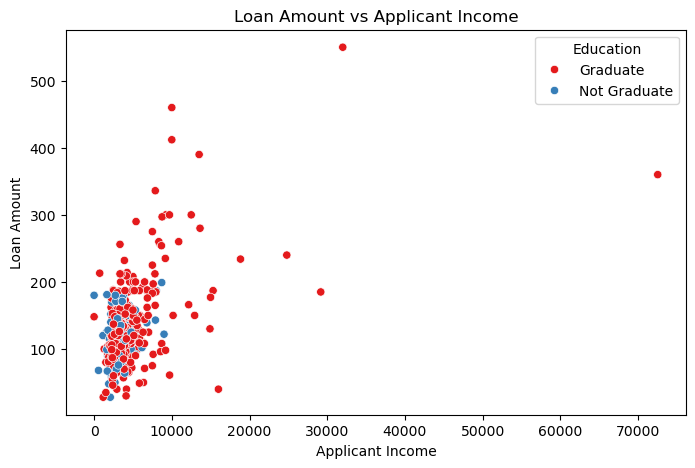

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='ApplicantIncome', y='LoanAmount', hue='Education', data=df, palette='Set1')
plt.title("Loan Amount vs Applicant Income")
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")
plt.show()

In [23]:
#Total Income (Applicant + Coapplicant) vs Loan Amount

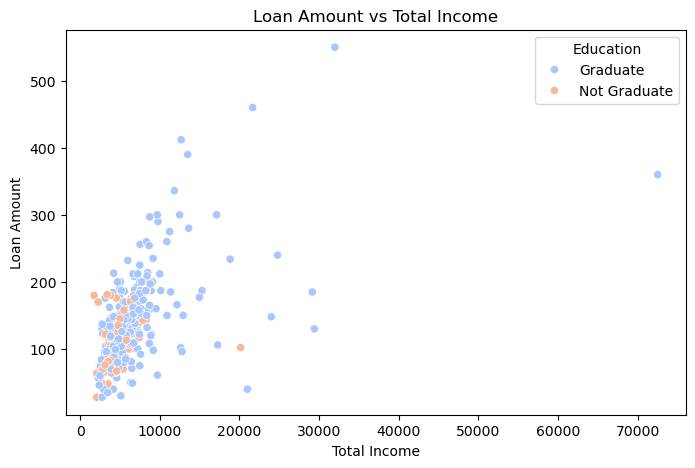

In [24]:
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

plt.figure(figsize=(8,5))
sns.scatterplot(x='TotalIncome', y='LoanAmount', hue='Education', data=df, palette='coolwarm')
plt.title("Loan Amount vs Total Income")
plt.xlabel("Total Income")
plt.ylabel("Loan Amount")
plt.show()

In [25]:
#Loan Amount by Property Area (Box Plot)

C:\Users\Mubarik Amin\AppData\Local\Temp\ipykernel_3708\195824819.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Property_Area', y='LoanAmount', data=df, palette='Set3')


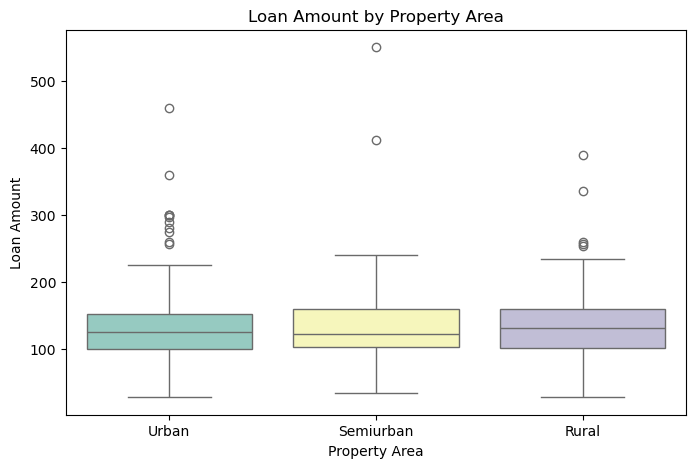

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Property_Area', y='LoanAmount', data=df, palette='Set3')
plt.title("Loan Amount by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Loan Amount")
plt.show()

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
# Fill numerical columns with median
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].median())

# Fill categorical columns with mode
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [33]:
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

In [34]:
categorical_cols.append('Loan')

In [36]:
print(df.columns)

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'TotalIncome'],
      dtype='object')


In [37]:
print([f"'{col}'" for col in df.columns])

["'Loan_ID'", "'Gender'", "'Married'", "'Dependents'", "'Education'", "'Self_Employed'", "'ApplicantIncome'", "'CoapplicantIncome'", "'LoanAmount'", "'Loan_Amount_Term'", "'Credit_History'", "'Property_Area'", "'TotalIncome'"]


In [38]:
categorical_cols = [col for col in categorical_cols if col in df.columns]

In [39]:
from sklearn.preprocessing import LabelEncoder

# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Keep only existing categorical columns
categorical_cols = [col for col in categorical_cols if col in df.columns]

label_encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

In [40]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,TotalIncome
0,LP001015,1,1,0,0,0,5720,0,110.0,360.0,1.0,2,5720
1,LP001022,1,1,1,0,0,3076,1500,126.0,360.0,1.0,2,4576
2,LP001031,1,1,2,0,0,5000,1800,208.0,360.0,1.0,2,6800
3,LP001035,1,1,2,0,0,2340,2546,100.0,360.0,1.0,2,4886
4,LP001051,1,0,0,1,0,3276,0,78.0,360.0,1.0,2,3276
